(phillips_two_stories)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 美国通货膨胀的兴衰

```{index} single: Phillips Curve; Rise and Fall of U.S. Inflation
```

```{contents} Contents
:depth: 2
```

除了 Anaconda 中已有的库之外，本讲座还将使用以下库来下载和过滤宏观经济数据：

In [1]:
!pip install pandas_datareader

## 概述

这是基于托马斯·萨金特《美国通货膨胀的征服》（*The Conquest of American Inflation* {cite}`Sargent1999`）的系列讲座中的第一讲。

它综合了该书第一章和第二章的内容。

这个系列提出了一个关于战后美国宏观经济史的问题：

> 如果我们认为通货膨胀是由美联储控制的，那么我们该如何解释美国通货膨胀在 20 世纪 70 年代的上升，以及在 20 世纪 80 年代初保罗·沃尔克治下的骤然下降？

这篇文章评估了两种解释，两者都基于政策制定者对菲利普斯曲线的*信念*。

在这两个故事中，美联储都是通过经验与*先验*推理相结合的方式，学到了自然失业率理论。

两个故事的区别在于该理论是如何被采纳的：

* **自然率理论的胜利。** 学术经济学家发现了自然率假说，指出任何通货膨胀与失业之间的权衡都是暂时的，并最终说服政策制定者追求低通货膨胀。
* **计量经济学政策评估的平反。** 政策制定者从未放弃罗伯特·卢卡斯在其著名批判中所抨击的方法。
  - 他们反复重新估计菲利普斯曲线并用它来选择目标，正是*数据本身*——一条不断向不利方向漂移的经验菲利普斯曲线——引导他们走向更低的通货膨胀。

本讲座介绍了支持这两个故事的事实，勾勒出这两种解释，并回顾了第二章既援引又修正的卢卡斯批判。

该系列的其余讲座建立了相应的模型：

* {doc}`phillips_credibility` —— 单期基德兰德-普雷斯科特（Kydland-Prescott）可信度问题（第三章）。
* {doc}`phillips_credible_policies` —— 重复经济中的声誉问题，以及为何可信政策理论用不可知论取代了悲观主义（第四章）。
* {doc}`phillips_adaptive` —— 适应性预期与菲尔普斯问题（第五章）。
* {doc}`phillips_misspecified` —— 最优错误设定信念下的均衡（第六章）。
* {doc}`phillips_self_confirming` —— 自我确认均衡（第七章）。
* {doc}`phillips_learning` —— 适应性学习、逃逸动态以及模拟的沃尔克稳定化过程（第八章）。
* {doc}`phillips_escaping_nash` —— 以分析方式刻画的逃逸动态（{cite}`ChoWilliamsSargent2002`）。
* {doc}`phillips_priors` —— 政府关于漂移系数的先验如何影响收敛、循环与逃逸（{cite}`SargentWilliams2005`）。
* {doc}`phillips_lost_conquest` —— 将同样的工具应用于 2020 年代的通货膨胀以及美联储的迟缓反应（{cite}`SargentWilliams2025`）。
* {doc}`phillips_drifts_volatilities` —— 一篇实证后记，将带漂移系数、随机波动率的向量自回归模型拟合到数据上，探讨大通胀究竟是政策不当还是运气不佳造成的（{cite}`CogleySargent2005`）。

(phillips_notation)=
### 关于记号的说明

各讲座遵循其各自所依据来源的记号约定，而这些来源彼此之间并不一致。

与其强加一套统一的记号方案、从而使读者难以对照可能想要参阅的原始论文，我们选择让每一讲都忠实于其来源，并在此记录各讲之间的记号对应关系。

| 对象 | 符号 | 出处 |
|---|---|---|
| 通货膨胀 | $y$ | {doc}`phillips_credibility` 至 {doc}`phillips_self_confirming` |
| | $\pi$ | 从 {doc}`phillips_escaping_nash` 起 |
| 公众的预期通货膨胀 | $x$ | {doc}`phillips_credibility`、{doc}`phillips_adaptive` |
| 政府的系统性通货膨胀 | $x$ | {doc}`phillips_escaping_nash`、{doc}`phillips_priors` |
| 自然失业率 | $U^*$ | {doc}`phillips_credibility` 至 {doc}`phillips_learning` |
| | $u$ | {doc}`phillips_escaping_nash`、{doc}`phillips_priors` |
| 菲利普斯曲线斜率 | $\theta$ | {doc}`phillips_credibility` 至 {doc}`phillips_escaping_nash` |
| 政府的信念 | $\gamma$ | {doc}`phillips_adaptive` 至 {doc}`phillips_priors` |
| | $\theta$ | {doc}`phillips_lost_conquest`、{doc}`phillips_drifts_volatilities` |
| 贴现因子 | $\delta$ | {doc}`phillips_credible_policies` 至 {doc}`phillips_learning` |
| | $\beta$ | {doc}`phillips_lost_conquest`、{doc}`phillips_drifts_volatilities` |
| 学习增益 | $\lambda$、$g_t$ | {doc}`phillips_adaptive`、{doc}`phillips_learning` |
| | $\varepsilon$ | {doc}`phillips_escaping_nash`、{doc}`phillips_priors` |

有三处符号冲突值得提前指出，因为如果读者把符号含义一路带下去，就会在这些地方被绊住。

字母 $x$ 换了阵营：在 {doc}`phillips_credibility` 中它表示*公众*的预期，而从 {doc}`phillips_escaping_nash` 起，它表示的是*政府*所设定的量。

二者在均衡中恰好相等，这正是这一转变容易被忽略的原因。

字母 $\theta$ 在前几讲中是菲利普斯曲线的斜率，而在最后两讲中则是政府的整个信念向量。

而 $\lambda$ 则身兼四职：在 {doc}`phillips_adaptive` 中是凯根-弗里德曼适应性参数，在 {doc}`phillips_learning` 中是遗忘因子，在 {doc}`phillips_priors` 中是先验紧缩参数，在 {doc}`phillips_lost_conquest` 中则是实测的持续性根。

让我们从一些导入开始：

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
from pandas_datareader import data as web
from statsmodels.tsa.filters.bk_filter import bkfilter

```{note}
接下来两节中的图表复现了 {cite}`Sargent1999` 第一章和第二章中的图表，这些图表所用的数据取自 20 世纪 90 年代末。

我们从 [FRED](https://fred.stlouisfed.org/) 下载相应的原始数据序列，并将关注范围限定在与原书相同的历史区间内。

之后的 {ref}`phillips_after_1999` 一节会将其中最具启发性的图表延伸到当下，并探讨这额外的四分之一个世纪的数据对这两个故事意味着什么。
```

## 事实

我们从整篇文章要解释的这一个事实开始：二战以来美国通货膨胀呈现的驼峰形走势。

我们用消费者价格指数（所有项目）月度变化的年化值来衡量通货膨胀，并用 13 个月的居中移动平均对其进行平滑，以去除季节性和高频噪声。

In [3]:
start, end = datetime.datetime(1948, 1, 1), datetime.datetime(1999, 1, 1)

cpi = web.DataReader('CPIAUCNS', 'fred', start, end)['CPIAUCNS']

# 年化月度通货膨胀率，再取 13 个月居中移动平均
inflation = 1200 * np.log(cpi).diff()
inflation_ma = inflation.rolling(13, center=True).mean()

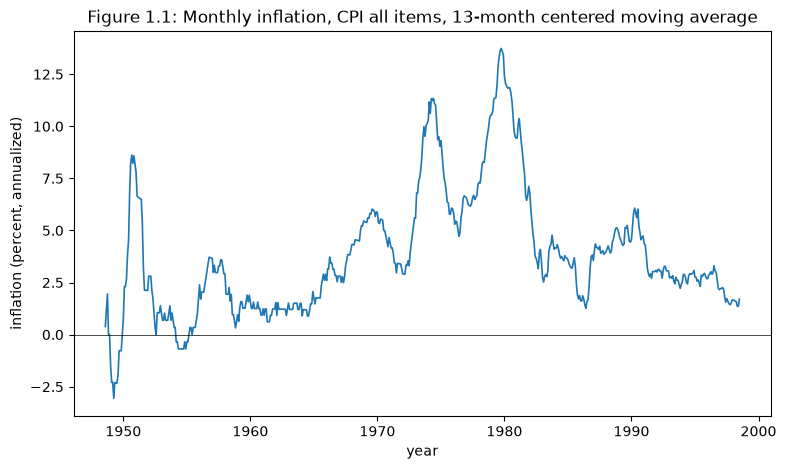

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(inflation_ma, lw=1.2)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('year')
ax.set_ylabel('inflation (percent, annualized)')
ax.set_title('Figure 1.1: Monthly inflation, CPI all items, '
             '13-month centered moving average')
plt.show()

在 20 世纪 50 年代末和 60 年代初，通货膨胀水平较低，随后在 70 年代急剧上升，接着又在 80 年代初随着沃尔克的稳定化政策而骤然下降。

任何将通货膨胀视为受美联储控制的解释，都必须说明这一上升与下降的过程。

## 数据中的菲利普斯曲线

尽管菲利普斯曲线在一些学术界和政策制定圈中名誉扫地，但它在美国数据中依然顽强存在，简单的方法就能将其检测出来。

为了从数据中提炼出菲利普斯曲线，我们沿用原书的两种做法。

第一，我们使用单一人口群体——20 岁及以上的白人男性——的失业率，而非整体失业率，因为整体失业率会受到人口结构缓慢变化的干扰。

第二，我们关注*商业周期*频率，滤除缓慢变化的成分，以便肉眼能够察觉通货膨胀与失业率之间的反向关系。

In [5]:
u = web.DataReader('LNS14000028', 'fred', start, end)['LNS14000028']  # white men 20+

data = pd.concat([inflation.rename('inflation'),
                  u.rename('unemployment')], axis=1).dropna()
data.head()

,inflation,unemployment
DATE,,
1954-01-01,0.000000,3.6
1954-02-01,0.000000,3.8
1954-03-01,0.000000,4.1
1954-04-01,-4.469279,4.7
1954-05-01,4.469279,4.6


图 1.2 将这两个原始序列绘制在一起。

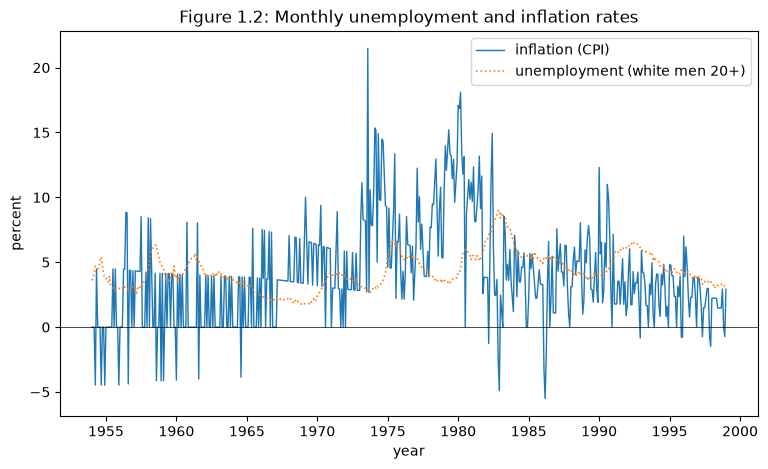

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(data.index, data['inflation'], 'C0', lw=1, label='inflation (CPI)')
ax.plot(data.index, data['unemployment'], 'C1:', lw=1.2,
        label='unemployment (white men 20+)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('year')
ax.set_ylabel('percent')
ax.set_title('Figure 1.2: Monthly unemployment and inflation rates')
ax.legend()
plt.show()

为了分离出商业周期层面的关系，我们采用巴克斯特（Baxter）和金（King）提出的有限滞后带通滤波器 {cite}`BaxterKing1999`。

按照原书的做法，我们保留周期在 24 到 84 个月之间的波动，并使用 84 个月的超前-滞后截断。

In [7]:
# Baxter-King bandpass: periods between 24 and 84 months, truncation 84
bk = bkfilter(data, low=24, high=84, K=84)
bk.columns = ['inflation_cycle', 'unemployment_cycle']

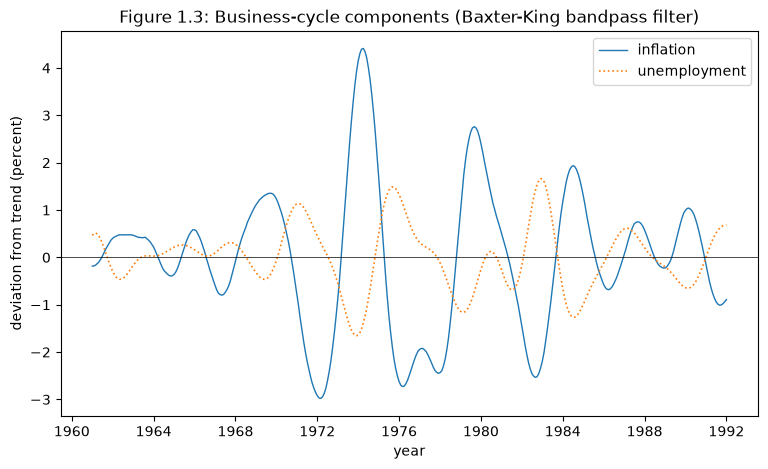

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(bk.index, bk['inflation_cycle'], 'C0', lw=1, label='inflation')
ax.plot(bk.index, bk['unemployment_cycle'], 'C1:', lw=1.2,
        label='unemployment')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('year')
ax.set_ylabel('deviation from trend (percent)')
ax.set_title('Figure 1.3: Business-cycle components '
             '(Baxter-King bandpass filter)')
ax.legend()
plt.show()

经过滤波的两个成分往往朝相反的方向变动：这是一条商业周期意义上的菲利普斯曲线。

我们可以在最令我们感兴趣的子时期——1960 年至 1982 年——的散点图中更直观地看到这种权衡关系。

图 1.4 将原始序列相互对照绘制，图 1.5 则展示了商业周期成分。

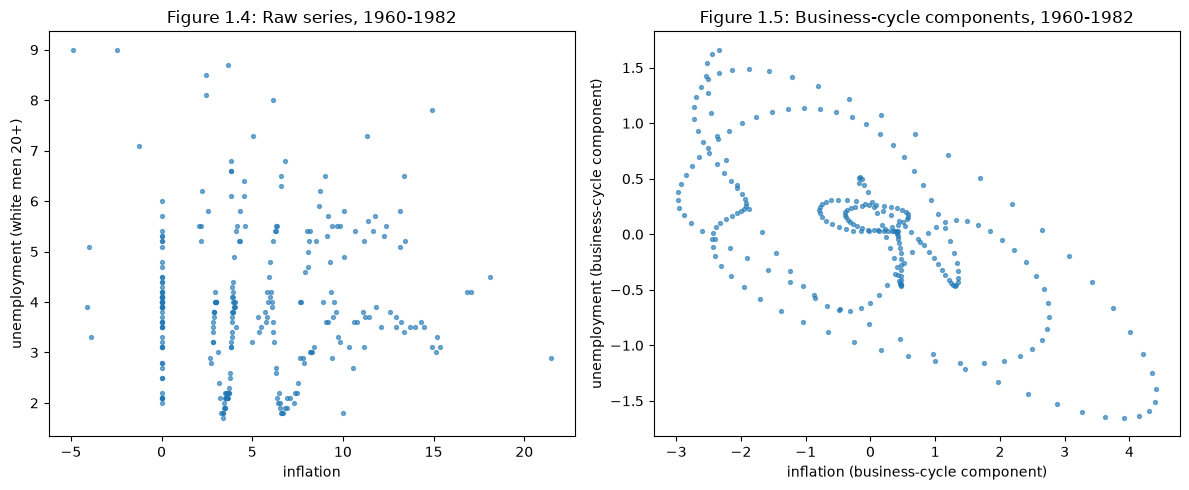

In [9]:
sub = slice('1960', '1982')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(data.loc[sub, 'inflation'],
                data.loc[sub, 'unemployment'], s=8, alpha=0.6)
axes[0].set_xlabel('inflation')
axes[0].set_ylabel('unemployment (white men 20+)')
axes[0].set_title('Figure 1.4: Raw series, 1960-1982')

axes[1].scatter(bk.loc[sub, 'inflation_cycle'],
                bk.loc[sub, 'unemployment_cycle'], s=8, alpha=0.6)
axes[1].set_xlabel('inflation (business-cycle component)')
axes[1].set_ylabel('unemployment (business-cycle component)')
axes[1].set_title('Figure 1.5: Business-cycle components, 1960-1982')

plt.tight_layout()
plt.show()

聚焦于商业周期成分使得表面上的菲利普斯曲线更加清晰。

图 1.5 揭示了**菲利普斯回路**：通货膨胀与失业率描绘出的是逆时针方向的回路，而非单一的稳定曲线，这正是自然率理论所强调的、位于故事核心的预期转变的特征表现。

```{note}
原书通过选取单一失业率序列来调整人口结构变化的影响。

若采用更广义的失业定义，就会引入额外的低频人口结构成分，人们可能会用单位根过程来对其建模。

而本文则从另一个来源——即摆脱布雷顿森林体系约束后货币当局*漂移的信念*——将单位根引入通货膨胀-失业率过程之中。
```

## 两种解释

这两个故事都从相同的初始条件出发——即政策制定者在 1960 年前后所继承的通货膨胀与失业史，以及当时的预期状态——而且都假设数据符合自然率假说，无论政策制定者当时是否意识到这一点。

### 自然率理论的胜利

对金本位制、继而对布雷顿森林体系的坚持，使美国得以维持低通货膨胀和低通货膨胀预期。

1960 年，保罗·萨缪尔森和罗伯特·索洛 {cite}`SamuelsonSolow1960` 在美国数据中发现了一条菲利普斯曲线，并宣称它是*可利用的*——即政策可以通过提高通货膨胀来降低失业率。

在不到十年的时间里，这一建议被广泛接受并付诸实施。

令所有人沮丧的是，菲利普斯曲线随后发生了不利的移动：通货膨胀上升了，但失业率平均而言并未下降。

与此同时，埃德蒙·费尔普斯（Edmund Phelps） {cite}`Phelps1967`、米尔顿·弗里德曼 {cite}`friedman1968role` 以及罗伯特·卢卡斯 {cite}`Lucas1972` 提出并完善了自然失业率的概念，该概念将通货膨胀预期置于确定菲利普斯曲线位置的核心地位。

自然率理论只允许*暂时性*的权衡取舍，并解释了这种不利的转移；其理性预期版本则意味着政策制定者应当忽视这种暂时的权衡，只应努力实现低通货膨胀。

在这个故事里，这些思想从学术界扩散到政策制定者手中，并最终带来了 20 世纪 80 年代和 90 年代较低的通货膨胀。

历史的走向由政策制定者的信念——有些是错误的，有些是正确的——以及这些信念所激发的行动共同塑造。

### 计量经济学政策评估的平反

另一种解释则将沃尔克的胜利部分归功于卢卡斯所质疑的那些计量经济学和政策制定程序本身的*成功*。

政策制定者接受了萨缪尔森-索洛菲利普斯曲线，将其视为一种可利用的权衡关系，并采用了他们从数据中学习并据此推导政策的方法。

他们反复重新估计一个分布滞后的菲利普斯曲线，并用它来重新设定目标通货膨胀率与失业率的组合。

如果机械地解读这一过程——不将预期识别为隐藏的状态变量——那么这条不断向不利方向移动的经验菲利普斯曲线最终引导政策制定者走向了更低的通货膨胀。

这个故事是用一种与理性预期相去甚微的*适应性*政策理论来讲述的。

它将该系列后续发展的一系列思想串联起来：漂移系数、自我确认均衡、最小二乘法及其他递归学习算法、最小二乘学习者向自我确认均衡的收敛，以及沿着从这些均衡中*逃逸的路径*所展现的周期性动态。

这一关键思想取自克里斯托弗·西姆斯（Christopher Sims） {cite}`Sims1988`，即适应性模型使政府能够从其过去利用菲利普斯曲线的尝试中*学习*，并最终发现某种版本的自然率假说，指导其降低通货膨胀。

## 忽略卢卡斯批判

该书第二章直面对平反故事的一个显而易见的质疑：卢卡斯批判难道不正是禁止使用那种机械的、可利用的菲利普斯曲线吗？而这正是平反故事的立论基础。

本文重新启用了卢卡斯曾坚决批判的计量经济学与政策评估程序 {cite}`lucas1976econometric`，并强调了其批判中一个被忽视的方面：**漂移系数**。

### 批判

一个计量经济学模型是一组随机差分方程的集合，其中一些描述了私人主体的决策规则。

丁伯根-泰尔（Tinbergen-Theil）传统中的计量经济学政策评估，是在政府针对某一目标函数优化自身规则的同时，将这些私人决策规则视为*固定不变*的。

卢卡斯指出，如果私人主体求解跨期最优化问题，那么他们的决策规则将*取决于*政府的规则。

由于忽略了这种依赖关系，丁伯根-泰尔方法错误地将政府对结果的偏好，转译为对决策规则的排序，从而给出不可靠的政策建议。

### 对漂移系数的诉求

卢卡斯承认凯恩斯主义模型在预测方面表现出色，但他认为，良好的预测表现并不能证明丁伯根-泰尔方法所假设的那种*干预下的不变性*成立。

他强调，预测者们习惯性地调整关键方程中的常数项，并将这些调整解读为一种与库利（Cooley）和普雷斯科特（Prescott） {cite}`CooleyPrescott1973` 思路一致的适应性系数模型。

所估计关系在跨期上的不稳定性——即系数漂移——削弱了将其视为对政策规则系统性变化保持不变的这种做法。

然而卢卡斯并未对这种漂移作出*解释*，而无论是批判之后建立的宏观经济理论，还是理性预期计量经济学，都没有对此作出说明：二者都聚焦于具有时不变转移函数的环境。

### 以参数漂移为出发点

本文以参数漂移为出发点，将其视为一个*确凿的证据*——这正是表明政府关于经济的信念、进而其通货膨胀政策，随时间演化的关键证据。

它由两个部分构建出一个模型：

1. 一个关于政府决策的丁伯根-泰尔理论——即 {doc}`phillips_adaptive` 中的费尔普斯问题；以及
2. 一个针对政府的漂移系数计量经济学程序，其中包含卢卡斯所描述的那种常数项调整。

在一个**自我确认均衡**（在 {doc}`phillips_self_confirming` 中展开）中，卢卡斯批判的部分效力便消失了。

尽管政府的不变性假设是错误的，但它并未在结果中受挫，因为这些结果在统计上与它的信念是一致的。

在自我确认均衡中，政府的信念*沿均衡路径*是正确的，因此其预测满足与理性预期均衡相同的跨方程约束；但相对于卢卡斯所使用的完全结构化模型而言，政府的模型所包含的自由参数*更少*——而恰恰正是这些缺失的参数，才是表现制度变迁所需要的。

要容纳制度变迁和漂移系数，就必须*抵制*向自我确认均衡的收敛。

本文通过用一种赋予近期数据更高权重的恒定增益、适应性系数算法，取代政府的最小二乘估计量，从而阻止这种收敛——这使政府具备了一种"环境可能不稳定"的疑虑。

这削弱了向自我确认均衡的牵引力，并维持了沿着某条逃逸路径的动态，制度变迁正是沿此路径发生的。

具有讽刺意味的是，正如我们将在 {doc}`phillips_learning` 中看到的那样，*违反*卢卡斯批判的程序，反而可能带来比遵循它的程序更好的结果。

## 一个尚早的总结：胜利还是平反？

本系列后续讲座将建立各种模型。

在我们开始之前，值得先预览一下这些模型将引向何方，以及它们留下的尚未解决的张力——这是对整个旅程的一个提前总结，改编自 {cite}`Sargent1999` 的结论章节。

一切都可以围绕两个*基准*模型来组织。

第一个模型源自 {cite}`Phelps1967`，公众以*适应性*方式形成预期，而政府在将公众的规则视为既定的前提下*最优地*选择政策。

第二个模型是理性预期自然率模型，其中公众是*理性的*，而政府的政策则被视为*外生且任意的*。

卢卡斯建议用第二个基准取代第一个。

正视这两个故事，促使我们提出在这两极之间做出各种*折衷*的模型——而后续讲座正是这些折衷方案。

### 前路展望

我们在 {doc}`phillips_credibility` 中开始，先在*双方*都施加理性的假设。

单期的 {cite}`KydlandPrescott1977` 模型得出了一个悲观的预测——即高通货膨胀的时间一致（纳什）结果——但可信政策理论的重复经济版本，用*不可知论*取代了这种悲观：太多的结果都变得可维持，以至于该理论只能给出微弱的预测。

{doc}`phillips_credible_policies` 证明了这一点，它用 {cite}`APS1990` 的递归方法计算出可维持数值的整个集合，并展示了三种带来相同收益却截然不同的均衡。

这种弱预测性是我们在宣称自然率理论取得胜利之前应当迟疑的第一个理由。

随后我们从卢卡斯批判处折返，重新从费尔普斯基准出发，但作一处改动：政府对私人部门的模型不再是任意的——它是*拟合历史数据*得到的。

改变这一拟合问题的各种细节，便产生了该系列的其余内容：

* 自我确认均衡（{doc}`phillips_self_confirming`），
* 具有最优*错误设定*预测函数的均衡（{doc}`phillips_misspecified`），以及
* 适应性、"预期效用"学习模型（{doc}`phillips_learning`、{doc}`phillips_escaping_nash` 和 {doc}`phillips_priors`）。

这些适应性模型是对理性预期一种*有节制的*退让，而非对其的彻底抛弃。

它们不包含控制预期的自由参数；在每一期，它们都施加与理性预期模型相同的跨方程约束；并且——由于自我确认均衡是其*均值动态*的吸引子——在平静的条件下它们会收敛回自我确认均衡，从而在均衡路径上收敛回理性预期，满足了 {cite}`Kreps1998` 所提出的一个诉求。

但是，遵循 {cite}`Sims1988` 的思路，我们真正感兴趣的是适应性所带来的*周期性*动态。

由于怀疑菲利普斯曲线容易发生漂移，政府使用了一种恒定增益算法，这在系数发生漂移时是明智的选择。

其成果颇为惊人：适应性模型产生了通货膨胀的骤然*稳定化*，这一结果违背了均值动态所指向的那种较差的自我确认结果。

这些制度转变既不是源于政府程序的任何改变，也不是源于巨大的冲击，而是源于*政府自身的计量经济学所引发的信念变化*——即在近似模型空间中逃逸路径的数学机制。

### 归纳假说：反派与英雄

这个故事的核心是**归纳假说**——即预期方程中滞后通货膨胀项的权重之和为一的这一限制，从而使得一个永久性更高的通货膨胀率最终会被完全预期到。

它几乎未经任何评论便被内嵌于 {cite}`Friedman1957` 和 {cite}`Cagan` 的适应性预期假说之中，并且是索洛与托宾对自然率假说所做早期检验的基础 {cite}`Solow1968,Tobin1968`。

在卢卡斯的批判中，它被塑造为*反派*角色——一种理性预期并不蕴含的天真限制——而在适应性模型中，归纳假说却又重新以*英雄*的身份出现：正是激活这一假说，才使得政府的费尔普斯问题呼唤出接近拉姆齐最优、低通货膨胀的政策。

我们的模拟所遵循的逃逸路径，恰恰就是政府所估计的模型——通过用单位根来近似一个常数——逐渐误入相信归纳假说的那些路径。

正是与此类近似问题的角力，以及同时存在若干个模型的情形，促使 {cite}`Sims1980` 将有限理性称为一片*荒野*，与理性预期那个整洁的单一模型世界截然不同。

### 保留意见

那么，究竟哪个故事才是正确的——胜利还是平反？

这场争论并非理性预期与其替代方案之间的对立，因为*两个*故事都是有选择性地采用或放弃理性预期。

而平反的故事，无论它多么契合数据，都只是一项*实证*经济学的练习，而非*规范*经济学的论断。

人们很容易把书中长期出现的接近拉姆齐最优的通货膨胀，解读为对产生这种结果的适应性政策制定程序的一种肯定——但这种诱惑应当被抵制。

因为正是那使得稳定化得以实现的同一套均值动态，也同样保证了这种稳定化只是暂时的：一旦信念漂移到足够接近归纳假说，均值动态便开始指向*远离*它的方向，回到费尔普斯问题建议重新推高通货膨胀的那个区域。

模拟结果中既包含了看起来像保罗·沃尔克的长时段，也包含了看起来像亚瑟·伯恩斯的长时段。

{cite}`KydlandPrescott1977` 以及 {cite}`Rogoff1985` 之后的理论研究坚持认为，持久的低通货膨胀必须依赖于*承诺机制*，使货币当局无法逐期相机抉择——而不能寄希望于一个装备了近似模型的适应性政府，能够碰巧最终学会大致做正确的事情。

因此，本书的结尾留下的是一种期望，而非定论：我们*希望*胜利的故事才是正确的那一个——即政策制定者已经学到了自然率假说的正确理性预期版本，并找到了使自己承诺于低通货膨胀的手段。

因为如果平反的故事更接近真相，那么曾经把通货膨胀拉低的同一套均值动态，也始终等待着最终把它重新推高。

自 1999 年以来的这四分之一个世纪的数据——一段长期而平静的*大缓和*，中间被 2021-2022 年的骤然飙升所打断——正是对这一期望的一次持续检验，接下来我们将转向对它的探讨。

(phillips_after_1999)=
## 1999 年之后的数据模式

{cite}`Sargent1999` 写于始于沃尔克的长期反通货膨胀过程结束之际。

如今我们又有了四分之一个世纪的新数据。

本节将把书中最具启发性的图表延伸到当下，并探讨这些新的观测数据对这两个故事意味着什么。

让我们把样本扩展到最新可获得的月份。

In [10]:
end_recent = datetime.datetime(2026, 7, 1)

cpi_full = web.DataReader('CPIAUCNS', 'fred', start, end_recent)['CPIAUCNS']
u_full = web.DataReader('LNS14000028', 'fred', start, end_recent)['LNS14000028']

# 原书所用的度量方式（月度变化年化值，13 个月居中移动平均）
inflation_full = 1200 * np.log(cpi_full).diff()
inflation_ma_full = inflation_full.rolling(13, center=True).mean()

# 同比通货膨胀率：更为平滑，也是当今通常引用的度量方式
inflation_yoy = 100 * (cpi_full / cpi_full.shift(12) - 1)

### 延伸后的兴与衰

图 1.1 展示了通货膨胀在 20 世纪 70 年代的上升以及在沃尔克治下的下降。

将其延伸至今，增添了原书所无法看到的三段历程：从 20 世纪 80 年代中期开始、通货膨胀低而稳定的*大缓和*时期；2008 年金融危机后，一段长期接近于零、并一度略低于零的时期；以及 2021-2022 年一次骤然飙升至 1981 年以来最高水平、随后又迅速回落的过程。

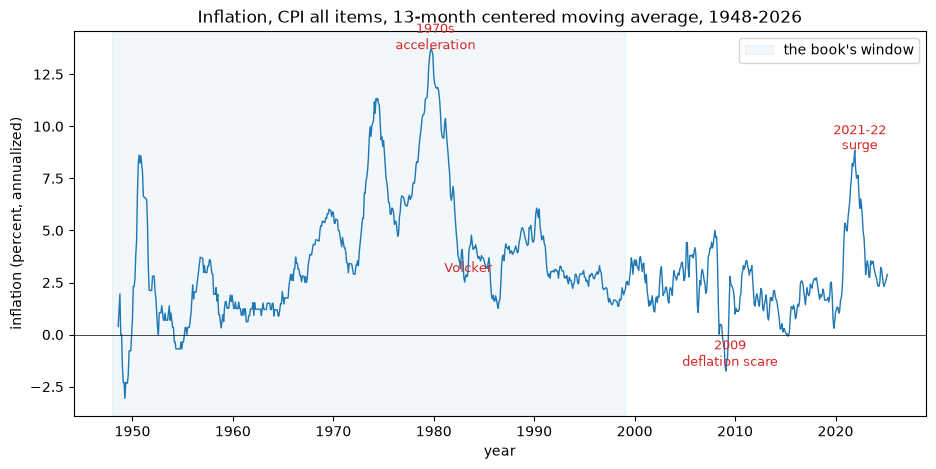

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(inflation_ma_full, lw=1)
ax.axhline(0, color='k', lw=0.5)
ax.axvspan(pd.Timestamp('1948-01-01'), pd.Timestamp('1999-01-01'),
           color='C0', alpha=0.06, label="the book's window")
for date, y, txt in [('1980-03-01', 13.7, '1970s\nacceleration'),
                     ('1983-06-01', 3.0, 'Volcker'),
                     ('2009-07-01', -1.5, '2009\ndeflation scare'),
                     ('2022-06-01', 8.9, '2021-22\nsurge')]:
    ax.annotate(txt, (pd.Timestamp(date), y), ha='center', fontsize=9,
                color='C3')
ax.set_xlabel('year')
ax.set_ylabel('inflation (percent, annualized)')
ax.set_title('Inflation, CPI all items, 13-month centered moving average, '
             '1948-2026')
ax.legend(loc='upper right')
plt.show()

原书所要解释的那个驼峰，如今变成了*两个*驼峰中的第一个。

第二个驼峰出现在 2021-2022 年，是一段真正意义上全新的经历——一次快速的加速，随后又几乎同样迅速地实现了反通货膨胀，整个过程被压缩在大约三年之内。

### 延续至今的失业率与通货膨胀

图 1.2 绘制了战后时期这两个序列的对比图。

将其延伸后，展示了新数据中最引人注目的两大宏观经济事件：2020 年新冠疫情导致的失业率骤升——一度是大萧条以来的最高水平——以及随之而来的通货膨胀飙升。

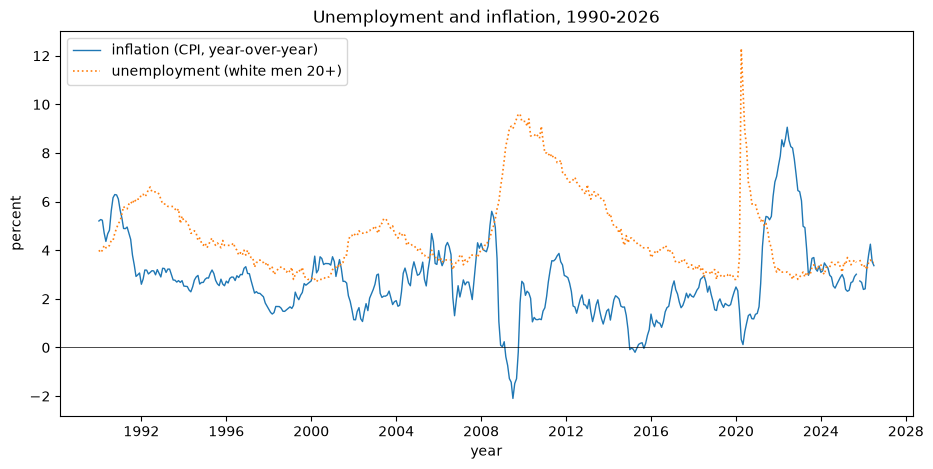

In [12]:
recent = slice('1990', None)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(inflation_yoy[recent], 'C0', lw=1, label='inflation (CPI, year-over-year)')
ax.plot(u_full[recent], 'C1:', lw=1.2, label='unemployment (white men 20+)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('year')
ax.set_ylabel('percent')
ax.set_title('Unemployment and inflation, 1990-2026')
ax.legend()
plt.show()

有两个特征十分突出。

从 20 世纪 90 年代中期到 2020 年，即使失业率大幅波动——在 90 年代末和 2019 年降至历史低点，又在 2008 年经济衰退中翻倍——通货膨胀却出奇地平静。

而在新冠疫情导致的失业率骤升之后，失业率又迅速回落，通货膨胀随即飙升——这一模式带有*供给*冲击的印记，而非经典菲利普斯曲线所描绘的那种需求驱动型权衡关系。

### 三个时代中的菲利普斯曲线

原书从 1960-1982 年的数据中提炼出了一条菲利普斯曲线。

1999 年之后最引人注目的模式，是通货膨胀与失业率的散点图在不同时代之间表现出的*不稳定性*。

我们将样本划分为原书所涉及的加速时期、大缓和时期，以及 2008 年之后的时期，并在每个时期分别绘制通货膨胀对失业率的散点图。

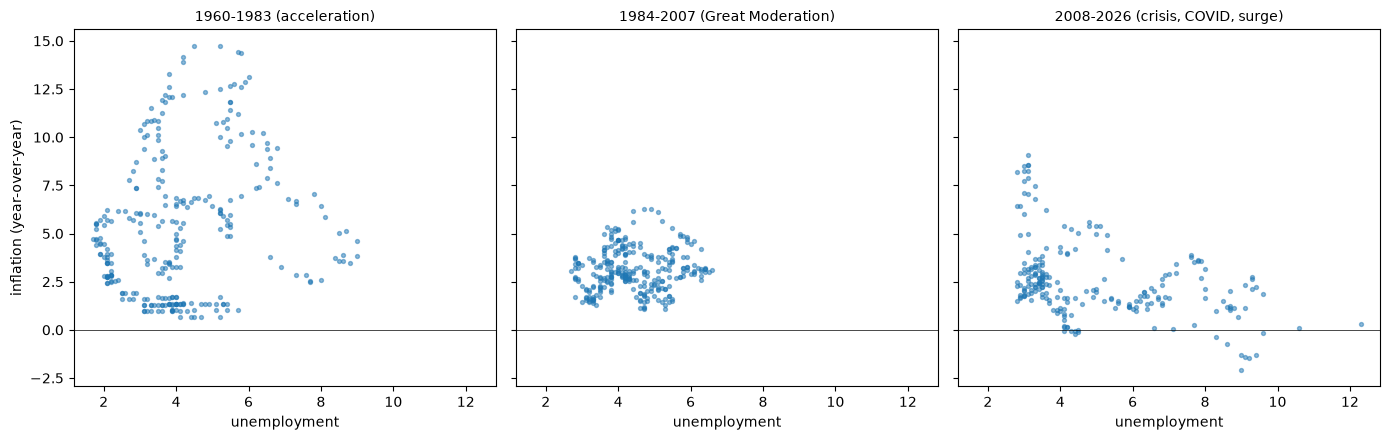

In [13]:
scatter_data = pd.concat([inflation_yoy.rename('inflation'),
                          u_full.rename('unemployment')], axis=1).dropna()

eras = [('1960', '1983', '1960-1983 (acceleration)'),
        ('1984', '2007', '1984-2007 (Great Moderation)'),
        ('2008', None, '2008-2026 (crisis, COVID, surge)')]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
for ax, (lo, hi, title) in zip(axes, eras):
    era_data = scatter_data.loc[lo:hi]
    ax.scatter(era_data['unemployment'], era_data['inflation'], s=8, alpha=0.5)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('unemployment')
    ax.set_title(title, fontsize=10)
axes[0].set_ylabel('inflation (year-over-year)')
plt.tight_layout()
plt.show()

在 1960-1983 年间，数据点散布在一个很宽的通货膨胀率范围内——这正是预期不断变化、菲利普斯曲线呈现*回路*形态的时代。

在 1984-2007 年间，它们收缩成一团紧密、低位、近乎平坦的点云——这就是大缓和时期，此时通货膨胀几乎对失业率毫无反应。

自 2008 年以来，这种关系瓦解成一片由两个离群点主导的散点：一个是新冠疫情引发的经济衰退，其特征是两位数的失业率与依然偏低的通货膨胀；另一个是 2021-2022 年的飙升，其特征是高通货膨胀与低失业率。

无论菲利普斯曲线究竟是什么，它都不是一种稳定的结构性关系——这恰恰正是促使本书提出*漂移信念*这一说法的那种不稳定性。

### 新数据对这两个故事意味着什么

这额外的四分之一个世纪的数据，既没有干净利落地推翻其中任何一个故事，也没有干净利落地证实它们，但它使两者都变得更加清晰。

**对自然率理论的胜利而言。**
大缓和时期可以被解读为这场胜利的最终完成：随着自然率共识的确立以及央行独立性的确立，通货膨胀在整整一代人的时间里保持低位，预期也保持*锚定*。

用本书的语言来说，经济安顿进入了一个低通货膨胀的自我确认均衡，并一直停留在那里。

即便是 2021-2022 年的飙升，按照这种解读，也支持了胜利的故事：一旦美联储采取果断行动，通货膨胀便迅速回落，长期预期从未失去锚定——低通货膨胀均衡经受住了一次巨大冲击的考验。

**对计量经济学政策评估的平反而言。**
这次飙升也提醒我们，货币当局的*模型*仍然可能误导它：2021 年广泛流行的"通货膨胀只是暂时的"观点，正是一个被数据证伪了的模型，而政策只是在信念发生转变之后才随之调整。

2020 年之前那十年近乎零通货膨胀的时期——那条看似*平坦*的菲利普斯曲线，既没有出现 2009-2013 年"消失的反通货膨胀"，也没有出现 2015-2019 年"消失的通货膨胀"，都不符合一条稳定曲线——恰恰正是本书中适应性政府会实时追踪其斜率和截距不断变化的那种漂移型经验关系。

```{note}
本书自身也会坚持提出这样一个警示：其机制假设*基本面*——即真实的数据生成过程——是稳定的，因此所有的作用都来自政府不断演化的信念。

2021-2022 年这一事件涉及了真实的供给冲击（疫情引发的中断、能源价格），这已超出了该假设的范围。

将信念的转变与基本面的转变区分开来，正是使这段历史如此难以捉摸、也如此引人入胜的那个识别问题。
```

本系列后续讲座中所建立的工具——自我确认均衡、漂移系数以及逃逸动态——仍然是探讨新数据所提出的这一问题的一种自然语言：一个可信的低通货膨胀均衡，是否会在每次冲击之后重新锚定，还是说一连串的意外仍可能使信念重新开始漂移，就像 1965 年之后所发生的那样？

{doc}`phillips_lost_conquest` 正是把这些工具应用于 2021-2022 年的飙升，并探讨了为什么美联储的反应如此迟缓，而收尾一讲 {doc}`phillips_drifts_volatilities` 则直接从数据出发，探讨战后宏观经济动态的系数究竟是否真的发生了漂移。

## 练习

```{exercise-start}
:label: ts_ex1
```

"聚焦于商业周期成分使得表面上的菲利普斯曲线更加清晰"这一论断，可以被定量地表述出来。

计算 1960-1982 年期间通货膨胀与失业率之间的相关系数，分别针对

* 原始序列（如图 1.4 所示），以及
* 巴克斯特-金商业周期成分（如图 1.5 所示）。

带通滤波将负向的菲利普斯相关性锐化了多少？

```{exercise-end}
```

```{solution-start} ts_ex1
:class: dropdown
```

In [14]:
corr_raw = data.loc[sub].corr().iloc[0, 1]
corr_cycle = bk.loc[sub].corr().iloc[0, 1]

print(f"raw correlation, 1960-1982        : {corr_raw:+.2f}")
print(f"business-cycle correlation, 1960-82: {corr_cycle:+.2f}")

raw correlation, 1960-1982        : +0.03
business-cycle correlation, 1960-82: -0.64


在原始序列中，相关系数接近于零：菲利普斯曲线的不利*移动*——即自然率理论所强调的那种缓慢移动的预期成分——淹没了商业周期层面的权衡关系。

一旦滤除这些低频移动，一种强烈的负相关关系便显现出来，证实了菲利普斯权衡关系是在商业周期频率上发挥作用的。

```{solution-end}
```